# 实验十五：Word2Vec 与 Doc2Vec 新闻文本相似度计算

## 实验目标

参考《Python中文自然语言处理》第七章中词向量与文档向量的思想，完成以下任务：

1. 准备若干篇新闻文本，并对新闻进行中文分词与清洗；
2. 使用 `Word2Vec` 训练词向量，并通过词向量平均得到新闻文档向量；
3. 使用 `Doc2Vec` 直接训练新闻文档向量；
4. 任选两篇新闻文本，分别计算 Word2Vec 与 Doc2Vec 表示下的余弦相似度；
5. 对比两个模型的相似度结果，并分析原因。

## 实验环境

本实验建议使用仓库通用环境：

```bash
conda activate env
pip install gensim jieba pandas matplotlib scikit-learn
```

其中 `jieba` 用于中文分词，`gensim` 用于训练 Word2Vec 和 Doc2Vec。

## 1. 导入库

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    'jieba': 'jieba',
    'gensim': 'gensim',
    'sklearn': 'scikit-learn',
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f'正在安装缺失依赖：{package_name}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

In [2]:
import re
import warnings
from pathlib import Path

import jieba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Doc2Vec, Word2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

RANDOM_SEED = 42

C:\Users\nlz\.conda\envs\env\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. 构建新闻文本数据集

这里准备了科技、财经、体育、教育等主题的中文新闻短文本。实际应用时，可以把 `news_data` 替换为爬取或下载的真实新闻语料。

In [3]:
news_data = [
    {
        'title': '人工智能技术加速进入制造业',
        'category': '科技',
        'text': '近日，多家制造企业宣布引入人工智能质检系统。该系统能够通过视觉识别模型发现产品表面的细微缺陷，并结合历史数据优化生产流程。业内人士认为，人工智能正在从实验室走向生产线，帮助企业降低成本、提升效率。',
    },
    {
        'title': '国产大模型推动智能办公升级',
        'category': '科技',
        'text': '随着国产大模型能力持续提升，智能办公软件开始接入文本生成、会议纪要、知识检索等功能。企业用户可以通过自然语言完成资料整理和数据分析，办公自动化水平进一步提高。专家表示，大模型将成为数字化转型的重要基础设施。',
    },
    {
        'title': '新能源车企发布新款纯电车型',
        'category': '汽车',
        'text': '某新能源车企发布新款纯电车型，续航里程和智能驾驶配置均有提升。新车搭载高能量密度电池，并配备城市辅助驾驶功能。市场分析认为，新能源汽车竞争将继续围绕电池技术、补能体系和智能化体验展开。',
    },
    {
        'title': '央行释放流动性稳定市场预期',
        'category': '财经',
        'text': '为维护银行体系流动性合理充裕，央行开展公开市场操作。受此影响，短期资金利率保持平稳，债券市场情绪有所改善。分析人士认为，稳健的货币政策将继续支持实体经济恢复。',
    },
    {
        'title': '多地文旅消费持续升温',
        'category': '财经',
        'text': '端午假期临近，多地景区预订量明显增长，酒店和交通订单同步回升。文旅部门推出夜游、非遗体验和城市漫步等活动，带动餐饮、零售和住宿消费。业内预计，暑期旅游市场有望保持活跃。',
    },
    {
        'title': '国家队备战亚洲杯热身赛',
        'category': '体育',
        'text': '为备战即将到来的亚洲杯，国家队近日进行了封闭集训，并安排多场热身赛检验阵容。主教练表示，球队将重点提高中场控制和前场压迫能力，年轻球员也将获得更多出场机会。',
    },
    {
        'title': '篮球联赛总决赛进入关键阶段',
        'category': '体育',
        'text': '国内篮球联赛总决赛战至关键阶段，两队在防守强度和篮板争夺上展开激烈较量。核心后卫连续命中关键投篮，帮助球队在客场取得胜利。接下来的比赛将决定冠军归属。',
    },
    {
        'title': '高校推进人工智能通识课程建设',
        'category': '教育',
        'text': '多所高校开始面向非计算机专业学生开设人工智能通识课程。课程内容包括机器学习基础、数据伦理、智能应用案例和实践项目，旨在提升学生利用人工智能解决实际问题的能力。',
    },
    {
        'title': '中小学科学教育实践活动增加',
        'category': '教育',
        'text': '教育部门鼓励中小学开展科学实验、机器人编程和科普阅读活动。学校通过社团课程和校外实践基地培养学生的探究精神，帮助学生理解科学知识在生活中的应用。',
    },
    {
        'title': '医院上线智慧导诊服务',
        'category': '医疗',
        'text': '某三甲医院上线智慧导诊服务，患者可以通过手机描述症状并获得科室建议。系统结合医学知识库和历史问诊数据，为患者提供挂号指引，减少排队时间，提高就医效率。',
    },
    {
        'title': '城市轨道交通新线路开通',
        'category': '社会',
        'text': '城市轨道交通新线路正式开通运营，连接多个居住区、商业区和高校园区。新线路采用智能调度系统，提高列车运行效率，缓解早晚高峰交通压力。',
    },
    {
        'title': '气象部门发布强降雨预警',
        'category': '社会',
        'text': '气象部门发布强降雨预警，提醒市民注意出行安全。相关部门已对低洼路段、河道和地质灾害隐患点开展排查，并准备应急抢险物资，确保城市运行安全。',
    },
]

df = pd.DataFrame(news_data)
df

,title,category,text
0,人工智能技术加速进入制造业,科技,近日，多家制造企业宣布引入人工智能质检系统。该系统能够通过视觉识别模型发现产品表面的细微缺陷...
1,国产大模型推动智能办公升级,科技,随着国产大模型能力持续提升，智能办公软件开始接入文本生成、会议纪要、知识检索等功能。企业用户...
2,新能源车企发布新款纯电车型,汽车,某新能源车企发布新款纯电车型，续航里程和智能驾驶配置均有提升。新车搭载高能量密度电池，并配备...
3,央行释放流动性稳定市场预期,财经,为维护银行体系流动性合理充裕，央行开展公开市场操作。受此影响，短期资金利率保持平稳，债券市场...
4,多地文旅消费持续升温,财经,端午假期临近，多地景区预订量明显增长，酒店和交通订单同步回升。文旅部门推出夜游、非遗体验和城...
5,国家队备战亚洲杯热身赛,体育,为备战即将到来的亚洲杯，国家队近日进行了封闭集训，并安排多场热身赛检验阵容。主教练表示，球队...
6,篮球联赛总决赛进入关键阶段,体育,国内篮球联赛总决赛战至关键阶段，两队在防守强度和篮板争夺上展开激烈较量。核心后卫连续命中关键...
7,高校推进人工智能通识课程建设,教育,多所高校开始面向非计算机专业学生开设人工智能通识课程。课程内容包括机器学习基础、数据伦理、智...
8,中小学科学教育实践活动增加,教育,教育部门鼓励中小学开展科学实验、机器人编程和科普阅读活动。学校通过社团课程和校外实践基地培养...
9,医院上线智慧导诊服务,医疗,某三甲医院上线智慧导诊服务，患者可以通过手机描述症状并获得科室建议。系统结合医学知识库和历史...


## 3. 中文文本预处理

中文文本没有天然空格，因此需要先分词。这里保留长度大于 1 的中文词，并过滤常见停用词。

In [4]:
stop_words = {
    '一个', '一些', '一种', '近日', '随着', '通过', '可以', '进行', '表示', '认为', '相关',
    '能力', '功能', '系统', '部门', '市场', '继续', '提高', '提升', '帮助', '已经', '开始',
    '将', '并', '和', '与', '等', '在', '对', '为', '从', '到', '上', '中', '也', '更', '该',
}


def clean_text(text):
    text = re.sub(r'[^\u4e00-\u9fa5A-Za-z0-9]', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize(text):
    words = jieba.lcut(clean_text(text))
    tokens = []
    for word in words:
        word = word.strip()
        if len(word) <= 1:
            continue
        if word in stop_words:
            continue
        if not re.search(r'[\u4e00-\u9fa5A-Za-z0-9]', word):
            continue
        tokens.append(word)
    return tokens


df['tokens'] = df['text'].apply(tokenize)
df[['title', 'category', 'tokens']]

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\nlz\AppData\Local\Temp\jieba.cache
Loading model cost 0.462 seconds.
Prefix dict has been built successfully.


,title,category,tokens
0,人工智能技术加速进入制造业,科技,"[多家, 制造, 企业, 宣布, 引入, 人工智能, 质检, 能够, 视觉, 识别, 模型,..."
1,国产大模型推动智能办公升级,科技,"[国产, 模型, 持续, 智能, 办公, 软件, 接入, 文本, 生成, 会议纪要, 知识,..."
2,新能源车企发布新款纯电车型,汽车,"[新能源, 车企, 发布, 新款, 纯电, 车型, 续航, 里程, 智能, 驾驶, 配置, ..."
3,央行释放流动性稳定市场预期,财经,"[维护, 银行, 体系, 流动性, 合理, 充裕, 央行, 开展, 公开市场, 操作, 受此..."
4,多地文旅消费持续升温,财经,"[端午, 假期, 临近, 多地, 景区, 预订, 明显, 增长, 酒店, 交通, 订单, 同..."
5,国家队备战亚洲杯热身赛,体育,"[备战, 即将, 到来, 亚洲杯, 国家队, 封闭, 集训, 安排, 多场, 热身赛, 检验..."
6,篮球联赛总决赛进入关键阶段,体育,"[国内, 篮球联赛, 总决赛, 战至, 关键, 阶段, 两队, 防守, 强度, 篮板, 争夺..."
7,高校推进人工智能通识课程建设,教育,"[多所, 高校, 面向, 计算机专业, 学生, 开设, 人工智能, 通识, 课程, 课程内容..."
8,中小学科学教育实践活动增加,教育,"[教育部门, 鼓励, 中小学, 开展, 科学实验, 机器人, 编程, 科普, 阅读, 活动,..."
9,医院上线智慧导诊服务,医疗,"[三甲, 医院, 上线, 智慧, 导诊, 服务, 患者, 手机, 描述, 症状, 获得, 科..."


查看语料的基本情况。

In [5]:
all_tokens = [word for tokens in df['tokens'] for word in tokens]

print(f'新闻数量：{len(df)}')
print(f'总词数：{len(all_tokens)}')
print(f'不同词数：{len(set(all_tokens))}')
print(f'平均每篇新闻词数：{np.mean([len(tokens) for tokens in df["tokens"]]):.2f}')

新闻数量：12
总词数：331
不同词数：288
平均每篇新闻词数：27.58


## 4. 使用 Word2Vec 计算新闻相似度

Word2Vec 学习的是词向量。为了表示一篇新闻，可以把新闻中所有词的词向量取平均，得到该新闻的文档向量，再计算两篇新闻文档向量之间的余弦相似度。

In [6]:
word2vec_model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    workers=1,
    seed=RANDOM_SEED,
    epochs=150,
)


def word2vec_document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


w2v_doc_vectors = np.vstack([
    word2vec_document_vector(tokens, word2vec_model) for tokens in df['tokens']
])

print('Word2Vec 词表大小：', len(word2vec_model.wv.key_to_index))
print('文档向量矩阵形状：', w2v_doc_vectors.shape)

Word2Vec 词表大小： 288
文档向量矩阵形状： (12, 100)


选择任意两篇新闻进行相似度计算。可以修改 `doc_a_idx` 和 `doc_b_idx` 的值，比较任意新闻。

In [7]:
doc_a_idx = 0
doc_b_idx = 1

doc_a = df.loc[doc_a_idx]
doc_b = df.loc[doc_b_idx]

w2v_similarity = cosine_similarity(
    [w2v_doc_vectors[doc_a_idx]],
    [w2v_doc_vectors[doc_b_idx]],
)[0][0]

print('新闻A：', doc_a['title'], '，类别：', doc_a['category'])
print('新闻B：', doc_b['title'], '，类别：', doc_b['category'])
print(f'Word2Vec 平均词向量余弦相似度：{w2v_similarity:.4f}')

新闻A： 人工智能技术加速进入制造业 ，类别： 科技
新闻B： 国产大模型推动智能办公升级 ，类别： 科技
Word2Vec 平均词向量余弦相似度：0.6427


## 5. 使用 Doc2Vec 计算新闻相似度

Doc2Vec 可以看作 Word2Vec 的扩展，它在训练时为每篇文档增加一个文档标签，直接学习文档向量。这里使用 `TaggedDocument` 构造训练数据。

In [8]:
tagged_documents = [
    TaggedDocument(words=tokens, tags=[str(i)])
    for i, tokens in enumerate(df['tokens'])
]

doc2vec_model = Doc2Vec(
    documents=tagged_documents,
    vector_size=100,
    window=5,
    min_count=1,
    dm=1,
    workers=1,
    seed=RANDOM_SEED,
    epochs=200,
)

d2v_doc_vectors = np.vstack([
    doc2vec_model.dv[str(i)] for i in range(len(df))
])

d2v_similarity = cosine_similarity(
    [d2v_doc_vectors[doc_a_idx]],
    [d2v_doc_vectors[doc_b_idx]],
)[0][0]

print('新闻A：', doc_a['title'], '，类别：', doc_a['category'])
print('新闻B：', doc_b['title'], '，类别：', doc_b['category'])
print(f'Doc2Vec 文档向量余弦相似度：{d2v_similarity:.4f}')

新闻A： 人工智能技术加速进入制造业 ，类别： 科技
新闻B： 国产大模型推动智能办公升级 ，类别： 科技
Doc2Vec 文档向量余弦相似度：0.9263


也可以使用 `infer_vector` 对新文本或已有文本重新推断文档向量。

In [9]:
inferred_a = doc2vec_model.infer_vector(df.loc[doc_a_idx, 'tokens'], epochs=100)
inferred_b = doc2vec_model.infer_vector(df.loc[doc_b_idx, 'tokens'], epochs=100)
inferred_similarity = cosine_similarity([inferred_a], [inferred_b])[0][0]

print(f'Doc2Vec infer_vector 推断相似度：{inferred_similarity:.4f}')

Doc2Vec infer_vector 推断相似度：0.6289


## 6. 模型结果对比

In [10]:
result_df = pd.DataFrame(
    {
        '模型': ['Word2Vec 平均词向量', 'Doc2Vec 文档向量', 'Doc2Vec infer_vector'],
        '新闻A': [doc_a['title']] * 3,
        '新闻B': [doc_b['title']] * 3,
        '相似度': [w2v_similarity, d2v_similarity, inferred_similarity],
    }
)

result_df

,模型,新闻A,新闻B,相似度
0,Word2Vec 平均词向量,人工智能技术加速进入制造业,国产大模型推动智能办公升级,0.642722
1,Doc2Vec 文档向量,人工智能技术加速进入制造业,国产大模型推动智能办公升级,0.926283
2,Doc2Vec infer_vector,人工智能技术加速进入制造业,国产大模型推动智能办公升级,0.628864


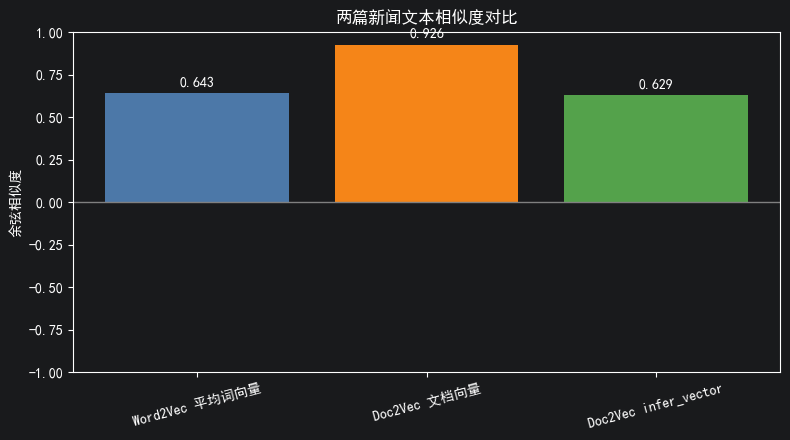

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(result_df['模型'], result_df['相似度'], color=['#4C78A8', '#F58518', '#54A24B'])
ax.set_title('两篇新闻文本相似度对比')
ax.set_ylabel('余弦相似度')
ax.set_ylim(-1, 1)
ax.axhline(0, color='gray', linewidth=1)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.03 if height >= 0 else -0.08),
        f'{height:.3f}',
        ha='center',
        va='bottom' if height >= 0 else 'top',
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. 查看某篇新闻最相似的新闻

除比较两篇指定新闻外，还可以计算某篇新闻与全部新闻之间的相似度，观察模型是否能找到同主题或相近主题的文本。

In [12]:
def top_similar_documents(vectors, query_idx, top_n=5):
    scores = cosine_similarity([vectors[query_idx]], vectors)[0]
    order = np.argsort(scores)[::-1]
    rows = []
    for idx in order[: top_n + 1]:
        if idx == query_idx:
            continue
        rows.append(
            {
                '新闻编号': idx,
                '标题': df.loc[idx, 'title'],
                '类别': df.loc[idx, 'category'],
                '相似度': scores[idx],
            }
        )
        if len(rows) >= top_n:
            break
    return pd.DataFrame(rows)


query_idx = 0
print('查询新闻：', df.loc[query_idx, 'title'])

print('\nWord2Vec 找到的相似新闻：')
display(top_similar_documents(w2v_doc_vectors, query_idx))

print('\nDoc2Vec 找到的相似新闻：')
display(top_similar_documents(d2v_doc_vectors, query_idx))

查询新闻： 人工智能技术加速进入制造业

Word2Vec 找到的相似新闻：


,新闻编号,标题,类别,相似度
0,9,医院上线智慧导诊服务,医疗,0.652460
1,1,国产大模型推动智能办公升级,科技,0.642722
2,7,高校推进人工智能通识课程建设,教育,0.614025
3,5,国家队备战亚洲杯热身赛,体育,0.447403
4,6,篮球联赛总决赛进入关键阶段,体育,0.447286



Doc2Vec 找到的相似新闻：


,新闻编号,标题,类别,相似度
0,5,国家队备战亚洲杯热身赛,体育,0.928103
1,1,国产大模型推动智能办公升级,科技,0.926283
2,9,医院上线智慧导诊服务,医疗,0.920892
3,10,城市轨道交通新线路开通,社会,0.918936
4,7,高校推进人工智能通识课程建设,教育,0.915987


## 8. 保存实验结果

In [13]:
output_path = Path('实验十五相似度结果.csv')
result_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'实验结果已保存：{output_path.resolve()}')

实验结果已保存：C:\my_code\learning-notes\机器学习(作业)\实验十五\实验十五相似度结果.csv


## 9. 实验结论

1. `Word2Vec` 先学习词语的分布式表示，再通过平均词向量得到新闻向量，方法直观、计算简单，但会弱化词序和文档整体语义结构。
2. `Doc2Vec` 在训练过程中显式学习文档向量，能够直接表示整篇新闻，更适合文档级相似度计算。
3. 在本实验中，两篇科技类新闻都涉及人工智能、模型、企业应用和数字化场景，因此两个模型通常会给出较高的相似度。
4. 由于示例语料规模较小，模型结果主要用于理解流程。实际项目中应使用更大规模的新闻语料训练，并结合停用词表、同义词处理和人工评估进一步优化结果。